Observed frequencies:
        Online  Offline  Hybrid
Male        30       45      25
Female      50       25      25

Expected frequencies:
        Online  Offline  Hybrid
Male      40.0     35.0    25.0
Female    40.0     35.0    25.0

Chi-square statistic = 10.7143
Degrees of freedom   = 2
Chi-square critical  = 5.9915
p-value              = 0.004714

Decision: Reject H0 -> Learning-mode preference depends on gender.


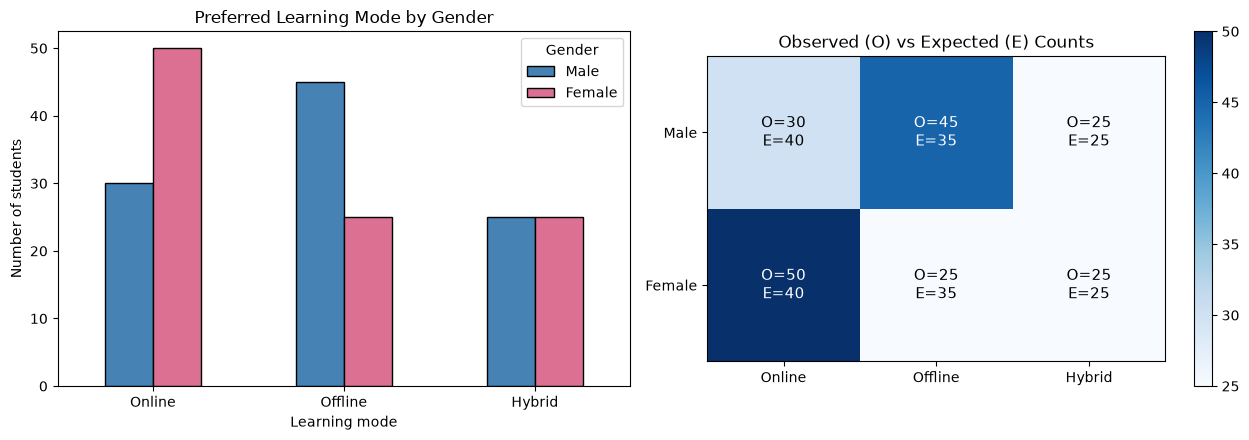

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

# Step 1: Contingency table
table = pd.DataFrame(
    [
        [30, 45, 25],
        [50, 25, 25]
    ],
    index=['Male', 'Female'],
    columns=['Online', 'Offline', 'Hybrid']
)

print("Observed frequencies:")
print(table)

alpha = 0.05

# Step 2: Chi-square test of independence
chi2_stat, p_value, df, expected = stats.chi2_contingency(table)

print("\nExpected frequencies:")
print(
    pd.DataFrame(
        expected,
        index=table.index,
        columns=table.columns
    ).round(2)
)

chi2_critical = stats.chi2.ppf(
    1 - alpha,
    df
)

print(f"\nChi-square statistic = {chi2_stat:.4f}")
print(f"Degrees of freedom   = {df}")
print(f"Chi-square critical  = {chi2_critical:.4f}")
print(f"p-value              = {p_value:.6f}")

# Step 3: Decision
if p_value < alpha:
    print(
        "\nDecision: Reject H0 -> "
        "Learning-mode preference depends on gender."
    )
else:
    print(
        "\nDecision: Fail to reject H0 -> "
        "Learning-mode preference is independent of gender."
    )

# Step 4: Graphs
fig, ax = plt.subplots(
    1,
    2,
    figsize=(13, 4.5)
)

# Graph 1: Grouped bar chart
table.T.plot(
    kind='bar',
    ax=ax[0],
    color=['steelblue', 'palevioletred'],
    edgecolor='black',
    rot=0
)

ax[0].set_title(
    'Preferred Learning Mode by Gender'
)

ax[0].set_xlabel(
    'Learning mode'
)

ax[0].set_ylabel(
    'Number of students'
)

ax[0].legend(
    title='Gender',
    loc='upper right'
)

# Graph 2: Heatmap
im = ax[1].imshow(
    table.values,
    cmap='Blues'
)

ax[1].set_xticks(range(3))
ax[1].set_xticklabels(table.columns)

ax[1].set_yticks(range(2))
ax[1].set_yticklabels(table.index)

# Add O and E values
for i in range(2):
    for j in range(3):

        if table.values[i, j] > 40:
            text_color = 'white'
        else:
            text_color = 'black'

        ax[1].text(
            j,
            i,
            f'O={table.values[i, j]}\nE={expected[i, j]:.0f}',
            ha='center',
            va='center',
            fontsize=11,
            color=text_color
        )

ax[1].set_title(
    'Observed (O) vs Expected (E) Counts'
)

plt.colorbar(
    im,
    ax=ax[1]
)

plt.tight_layout()
plt.show()